In [25]:
import matplotlib.pyplot as plt 
import pandas as pd

file_path = "sam2_grid_search_runs_excerpt.xlsx"  # update this path
df_xls = pd.read_excel(file_path, skiprows=3)

df_xls = df_xls.rename(columns={"mean_error": "mean_error_rate", "mean_unseg": "mean_unseg_rate", "mean_time_sec":"mean_generate_time"})
df_xls.head()



,Run #,Total Runs Reported,points_per_side,pred_iou_thresh,stability_score_thresh,crop_n_layers,crop_n_points_downscale_factor,box_nms_thresh,min_mask_region_area,score,mean_error_rate,mean_unseg_rate,mean_generate_time,postprocess_warning,params_json
0,1,216,32,0.8,0.8,1,1,0.3,50,0.385949,0.052292,0.333657,25.845,cannot import name '_C' from 'sam2'; post-proc...,"{""points_per_side"": 32, ""pred_iou_thresh"": 0.8..."
1,2,216,32,0.8,0.8,1,1,0.3,100,0.385949,0.052292,0.333657,25.770,cannot import name '_C' from 'sam2'; post-proc...,"{""points_per_side"": 32, ""pred_iou_thresh"": 0.8..."
2,3,216,32,0.8,0.8,1,1,0.7,50,0.293160,0.052705,0.240455,25.760,cannot import name '_C' from 'sam2'; post-proc...,"{""points_per_side"": 32, ""pred_iou_thresh"": 0.8..."
3,4,216,32,0.8,0.8,1,1,0.7,100,0.293160,0.052705,0.240455,25.753,cannot import name '_C' from 'sam2'; post-proc...,"{""points_per_side"": 32, ""pred_iou_thresh"": 0.8..."
4,5,216,32,0.8,0.8,2,1,0.3,50,0.362918,0.049779,0.313139,105.511,cannot import name '_C' from 'sam2'; post-proc...,"{""points_per_side"": 32, ""pred_iou_thresh"": 0.8..."


In [26]:
file_path = "trial_summary.csv"  # update this path
df_csv = pd.read_csv(file_path)

df_csv.head()


,run_id,param_set_id,points_per_side,pred_iou_thresh,stability_score_thresh,crop_n_layers,crop_n_points_downscale_factor,box_nms_thresh,min_mask_region_area,n_images_total,n_images_ok,n_images_failed,n_images,mean_error_rate,mean_unseg_rate,mean_generate_time,mean_num_masks,std_error_rate,std_unseg_rate,score
0,coarse_run_002,0,32,0.65,0.65,1,1,0.70,50,13,13,0,13,0.048736,0.157275,27.695473,340.153846,0.109646,0.144392,0.206011
1,coarse_run_002,1,32,0.65,0.65,1,1,0.90,50,13,13,0,13,0.048679,0.155660,27.742773,346.615385,0.109456,0.143824,0.204339
2,coarse_run_002,2,32,0.65,0.65,1,1,0.95,50,13,13,0,13,0.048679,0.155598,27.719052,349.307692,0.109457,0.143903,0.204277
3,coarse_run_002,3,32,0.65,0.65,2,1,0.70,50,13,13,0,13,0.044623,0.136534,112.235240,834.615385,0.100964,0.134802,0.181158
4,coarse_run_002,4,32,0.65,0.65,2,1,0.90,50,13,13,0,13,0.044616,0.134003,113.466916,857.153846,0.100950,0.133734,0.178619


In [31]:
# Join on shared column names (excluding score to avoid overly strict matching)
common_cols = df_xls.columns.intersection(df_csv.columns).tolist()
print("Common columns:", common_cols)
df = pd.concat([df_xls[common_cols], df_csv[common_cols]], ignore_index=True)

Common columns: ['points_per_side', 'pred_iou_thresh', 'stability_score_thresh', 'crop_n_layers', 'crop_n_points_downscale_factor', 'box_nms_thresh', 'min_mask_region_area', 'score', 'mean_error_rate', 'mean_unseg_rate', 'mean_generate_time']


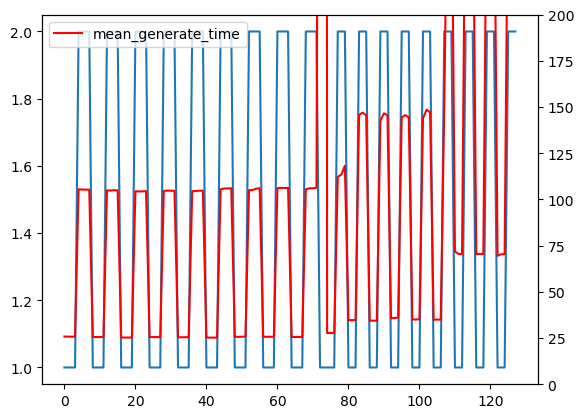

In [55]:
df['crop_n_layers'].plot()
ax = plt.twinx()
df['mean_generate_time'].plot(color='r')
ax.set_ylim([0, 200])
plt.legend()

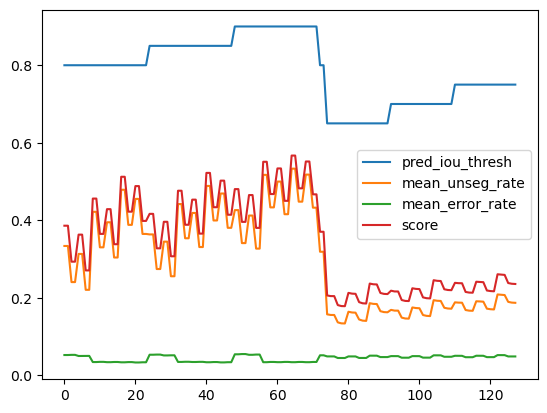

In [38]:
df['pred_iou_thresh'].plot()
df['mean_unseg_rate'].plot()
df['mean_error_rate'].plot()
df['score'].plot()
plt.legend()

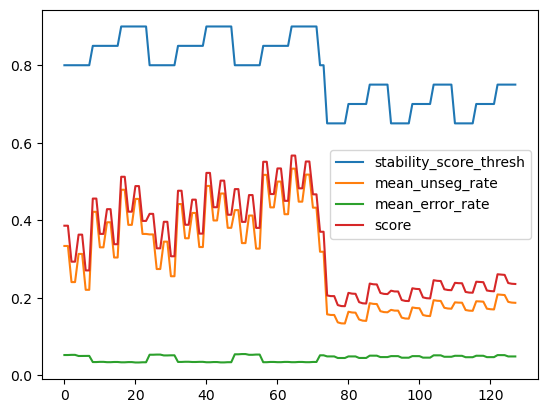

In [39]:
df['stability_score_thresh'].plot()
df['mean_unseg_rate'].plot()
df['mean_error_rate'].plot()
df['score'].plot()
plt.legend()

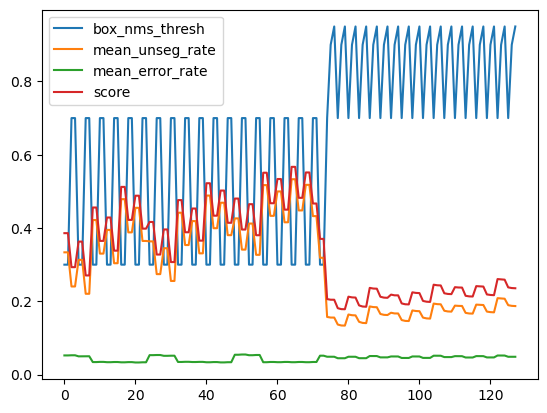

In [40]:
df['box_nms_thresh'].plot()
df['mean_unseg_rate'].plot()
df['mean_error_rate'].plot()
df['score'].plot()
plt.legend()

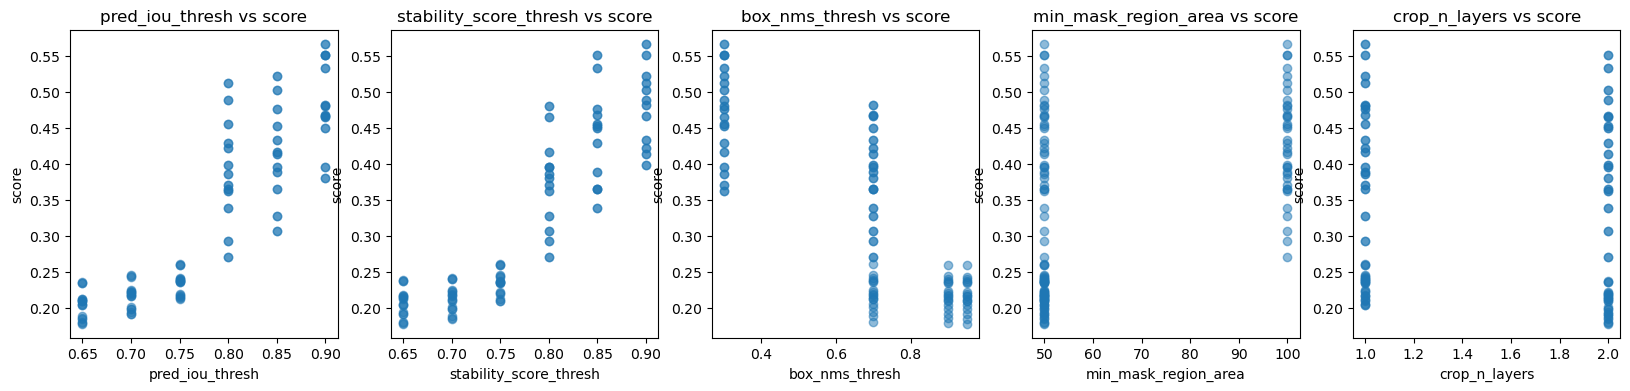

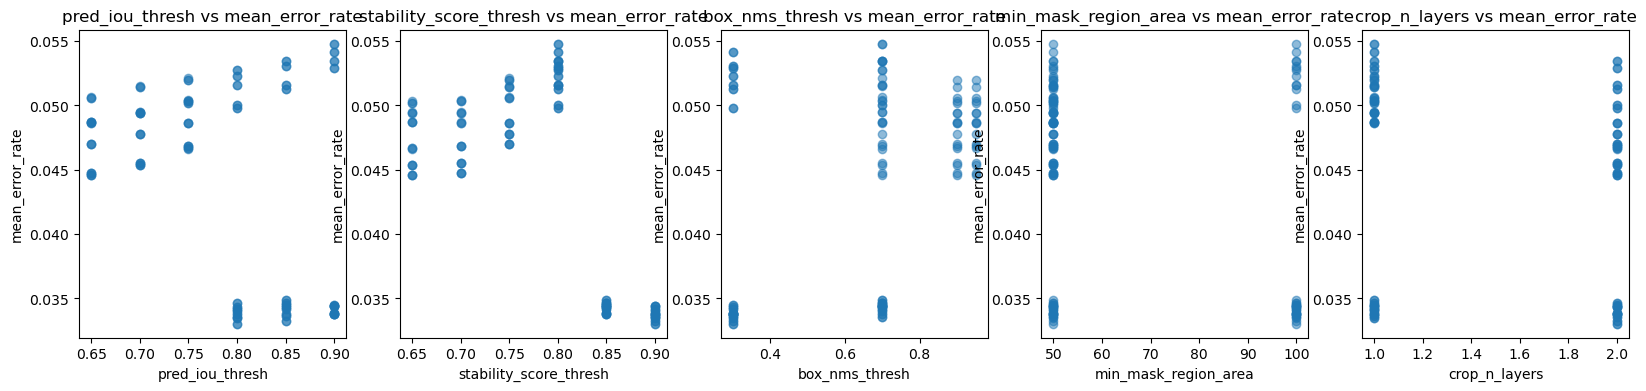

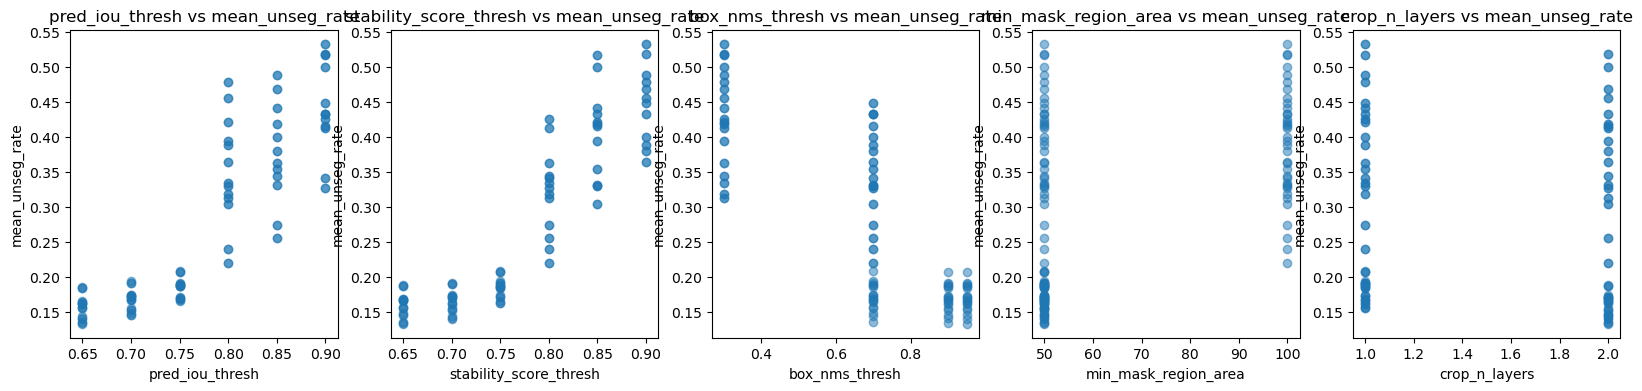

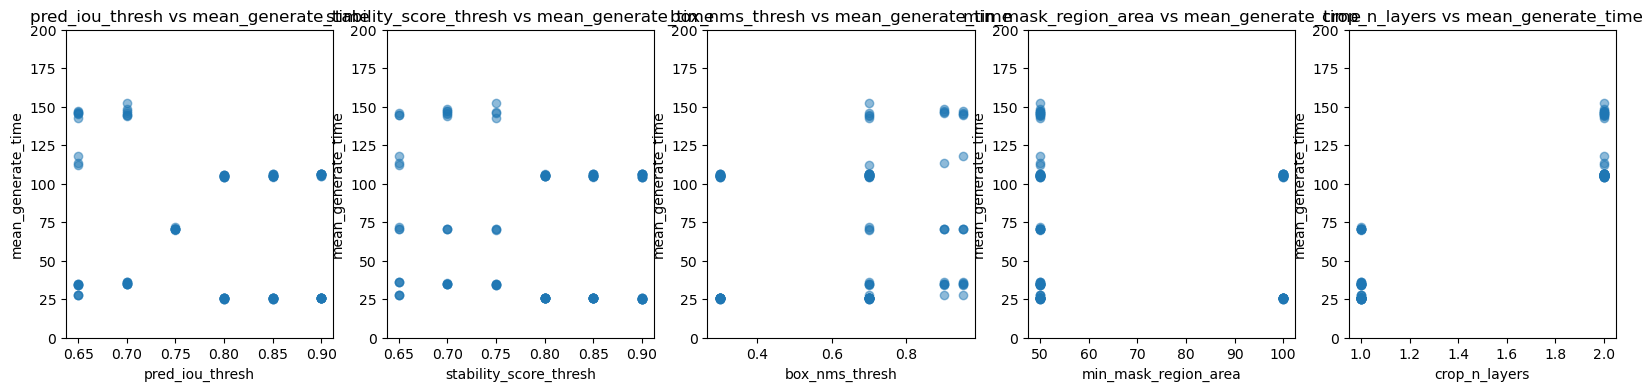

In [58]:
# Compare all numeric columns against score, mean_error, and mean_unseg
target_cols = ["score", "mean_error_rate", "mean_unseg_rate", 'mean_generate_time']


# Numeric-only correlation comparison
numeric_cols = ['pred_iou_thresh', 'stability_score_thresh', 'box_nms_thresh', 'min_mask_region_area', 'crop_n_layers']


for target_col in target_cols:
    fig, axs = plt.subplots(1, 5, figsize=(20, 4))
    for i, num_col in enumerate(numeric_cols):
        if num_col in target_cols:
            continue
        axs[i].scatter(df[num_col], df[target_col], alpha=0.5)
        axs[i].set_xlabel(num_col)
        axs[i].set_ylabel(target_col)
        axs[i].set_title(f"{num_col} vs {target_col}")
        if target_col == 'mean_generate_time':
            axs[i].set_ylim([0, 200])
    plt.show()

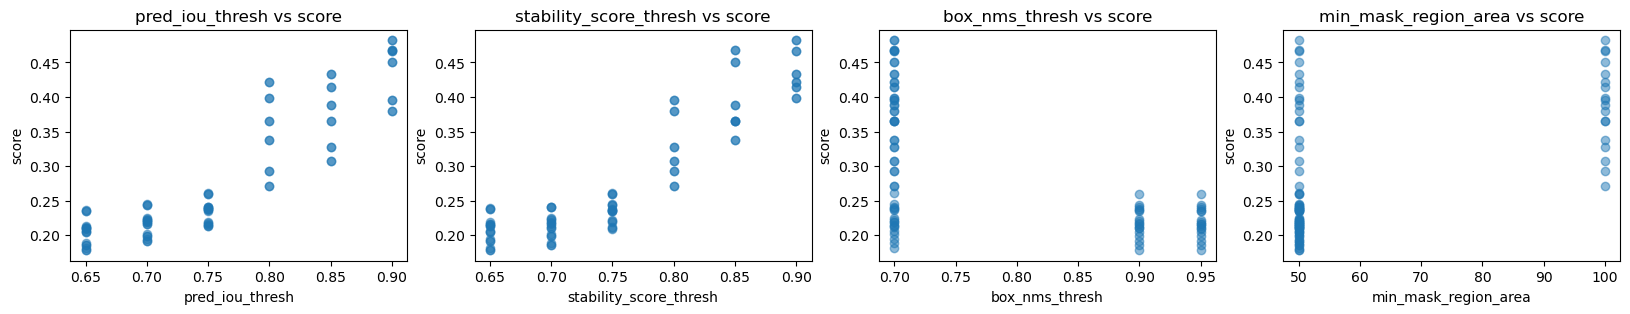

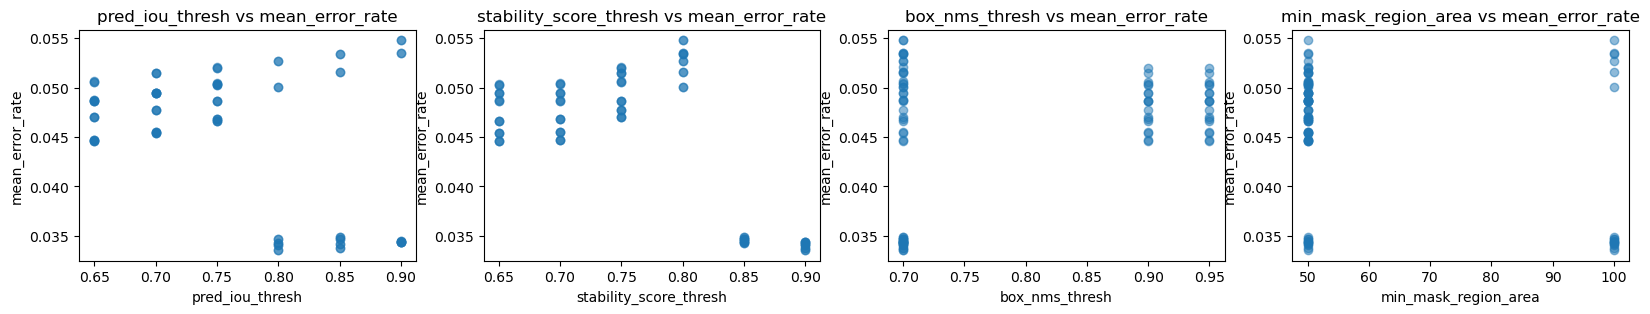

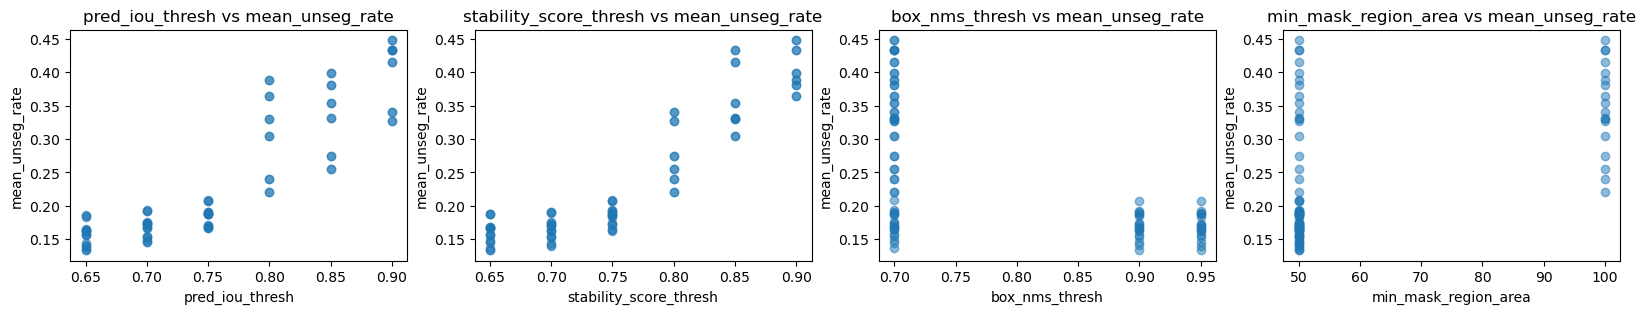

In [51]:
for target_col in target_cols:
    fig, axs = plt.subplots(1, 4, figsize=(20, 3))
    for i, num_col in enumerate(numeric_cols):
        if num_col in target_cols:
            continue
        axs[i].scatter(df[num_col][df['box_nms_thresh'] >= 0.7], df[target_col][df['box_nms_thresh'] >= 0.7], alpha=0.5)
        axs[i].set_xlabel(num_col)
        axs[i].set_ylabel(target_col)
        axs[i].set_title(f"{num_col} vs {target_col}")
    plt.show()